In [163]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# from trainer.src.influx_reader import load_data

# EDA

In [84]:
# df = load_data()

In [85]:
df = pd.read_csv("../datasets/sensors.csv", index_col=0)

## Dataset overview

In [86]:
df.shape

(11561, 11)

In [87]:
df.head()

,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
0,2026-08-13T08:54:27.354064+00:00,motor_000,15.35,0,44.0,0.558,6.02,2143.0,59.94,0.63,0.0001
1,2026-08-13T08:54:28.644359+00:00,motor_000,15.55,0,49.7,0.539,6.09,2151.0,58.60,0.52,0.0003
2,2026-08-13T08:54:29.659000+00:00,motor_000,14.02,0,45.0,0.540,5.98,2170.0,58.83,0.58,0.0004
3,2026-08-13T08:54:30.673773+00:00,motor_000,14.93,0,46.0,0.541,5.91,2178.0,58.44,0.51,0.0005
4,2026-08-13T08:54:31.678822+00:00,motor_000,14.79,0,39.9,0.542,6.04,2154.0,59.65,0.61,0.0007


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11561 entries, 0 to 11560
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         11561 non-null  str    
 1   device_id    11561 non-null  str    
 2   current      11561 non-null  float64
 3   failure      11561 non-null  int64  
 4   humidity     11561 non-null  float64
 5   load         11561 non-null  float64
 6   pressure     11561 non-null  float64
 7   rpm          11561 non-null  float64
 8   temperature  11561 non-null  float64
 9   vibration    11561 non-null  float64
 10  wear         11561 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 993.7 KB


In [89]:
df.describe()

,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
count,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000
mean,17.746659,0.003806,44.995987,0.699981,5.946397,2332.247989,65.328348,0.690173,0.025778
std,4.079930,0.061577,3.956554,0.218274,0.251728,292.075435,8.237194,0.348543,0.020452
min,1.510000,0.000000,26.900000,0.200000,1.580000,171.000000,45.510000,0.260000,0.000100
25%,14.710000,0.000000,42.300000,0.534000,5.920000,2140.000000,59.180000,0.580000,0.009200
50%,18.640000,0.000000,45.100000,0.748000,5.960000,2396.000000,66.800000,0.690000,0.020700
75%,21.110000,0.000000,47.700000,0.883000,6.000000,2558.000000,71.630000,0.770000,0.038000
max,24.480000,1.000000,61.100000,1.000000,6.190000,2754.000000,113.960000,6.930000,0.098800


In [90]:
df["device_id"].nunique()

4

In [91]:
df["device_id"].value_counts()

device_id
motor_000    2946
motor_001    2946
motor_002    2864
motor_003    2805
Name: count, dtype: int64

In [92]:
df.groupby("device_id")["time"].agg(["min", "max", "count"])

,min,max,count
device_id,,,
motor_000,2026-08-13T08:54:27.354064+00:00,2026-08-13T09:44:04.283908+00:00,2946
motor_001,2026-08-13T08:54:27.451405+00:00,2026-08-13T09:44:04.286234+00:00,2946
motor_002,2026-08-13T08:54:27.411811+00:00,2026-08-13T09:44:04.286031+00:00,2864
motor_003,2026-08-13T08:54:27.484919+00:00,2026-08-13T09:44:04.286050+00:00,2805


## Temporal structure

In [93]:
dft = df.copy()
dft["time"] = pd.to_datetime(dft["time"])
dft = dft.sort_values(["device_id", "time"])

In [94]:
time_range = (
    dft.groupby("device_id")["time"]
    .agg(
        start="min",
        end="max",
        observations="count"
    )
)

time_range["duration"] = time_range["end"] - time_range["start"]

In [95]:
time_range

,start,end,observations,duration
device_id,,,,
motor_000,2026-08-13 08:54:27.354064+00:00,2026-08-13 09:44:04.283908+00:00,2946,0 days 00:49:36.929844
motor_001,2026-08-13 08:54:27.451405+00:00,2026-08-13 09:44:04.286234+00:00,2946,0 days 00:49:36.834829
motor_002,2026-08-13 08:54:27.411811+00:00,2026-08-13 09:44:04.286031+00:00,2864,0 days 00:49:36.874220
motor_003,2026-08-13 08:54:27.484919+00:00,2026-08-13 09:44:04.286050+00:00,2805,0 days 00:49:36.801131


In [96]:
dft["dt"] = (
    dft.groupby("device_id")["time"]
    .diff()
    .dt.total_seconds()
)

sampling_stats = (
    dft.groupby("device_id")["dt"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        max="max",
        min="min",
    )
)

In [97]:
sampling_stats.head()

,mean,median,std,max,min
device_id,,,,,
motor_000,1.010842,1.007805,0.012595,1.290295,1.001463
motor_001,1.010810,1.007844,0.021318,2.021540,1.001278
motor_002,1.039774,1.007850,0.178585,3.038568,1.001472
motor_003,1.061627,1.007922,0.239876,4.020289,1.001251


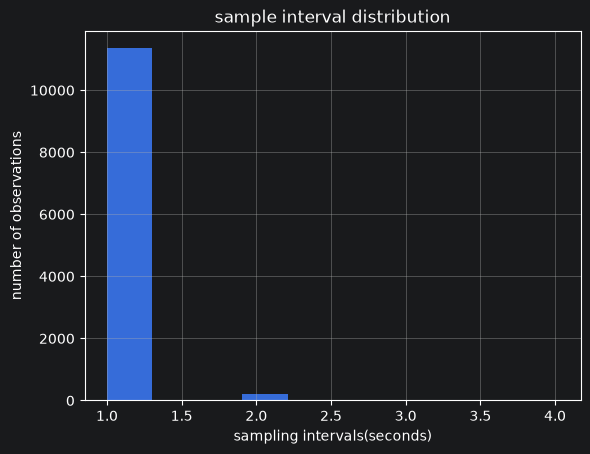

In [98]:
dft["dt"].dropna().hist()
plt.ylabel("number of observations")
plt.xlabel("sampling intervals(seconds)")
plt.title("sample interval distribution")
plt.show()

In [99]:
expected = 1
thresh = expected * 2

gaps = dft[(dft["dt"] > thresh) & dft["dt"].notna()]

In [100]:
gaps[["device_id", "time", "dt"]]

,device_id,time,dt
2979,motor_001,2026-08-13 08:55:02.179323+00:00,2.021540
5893,motor_002,2026-08-13 08:54:29.657802+00:00,2.245991
5914,motor_002,2026-08-13 08:54:52.093537+00:00,2.023801
5933,motor_002,2026-08-13 08:55:12.267378+00:00,2.008625
5948,motor_002,2026-08-13 08:55:28.343420+00:00,2.010395
...,...,...,...
11517,motor_003,2026-08-13 09:43:16.963043+00:00,2.022883
11518,motor_003,2026-08-13 09:43:18.989672+00:00,2.026629
11545,motor_003,2026-08-13 09:43:47.172753+00:00,2.018000
11546,motor_003,2026-08-13 09:43:49.182578+00:00,2.009825


In [101]:
gaps_by_device = gaps.groupby("device_id").size()
gaps_by_device

device_id
motor_001      1
motor_002     79
motor_003    132
dtype: int64

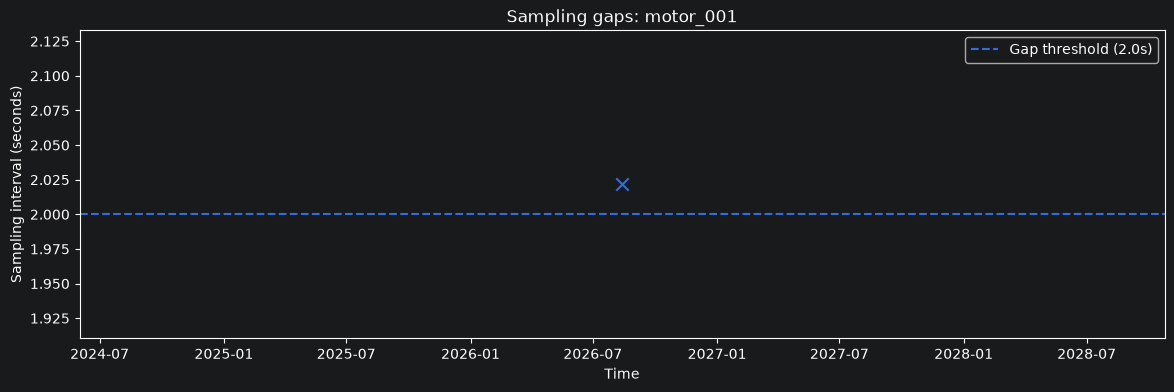

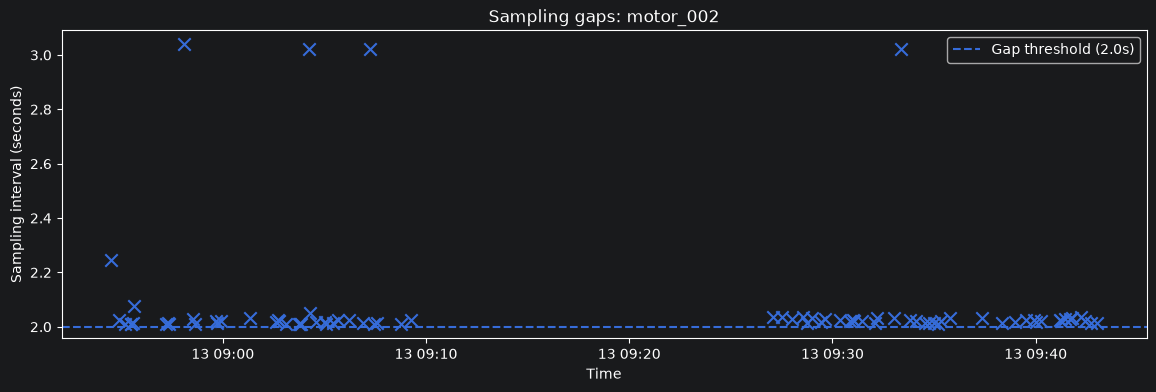

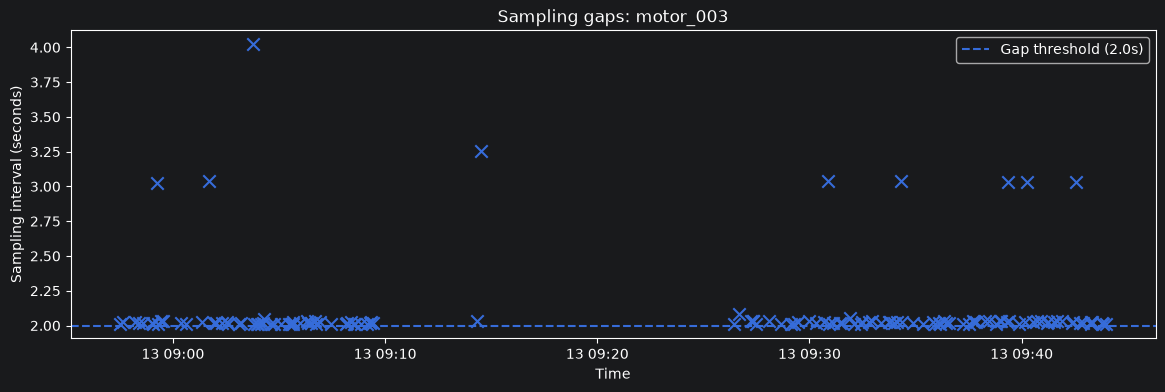

In [102]:
for device_id, device_gaps in gaps.groupby("device_id"):
    plt.figure(figsize=(14, 4))

    plt.scatter(
        device_gaps["time"],
        device_gaps["dt"],
        marker="x",
        s=80,
        zorder=2,
    )

    plt.axhline(
        thresh,
        linestyle="--",
        label=f"Gap threshold ({thresh:.1f}s)",
    )

    plt.title(f"Sampling gaps: {device_id}")
    plt.xlabel("Time")
    plt.ylabel("Sampling interval (seconds)")
    plt.legend()
    plt.show()

## Features distribution

In [103]:
features = df.columns.drop('time').drop('device_id')
features

Index(['current', 'failure', 'humidity', 'load', 'pressure', 'rpm',
       'temperature', 'vibration', 'wear'],
      dtype='str')

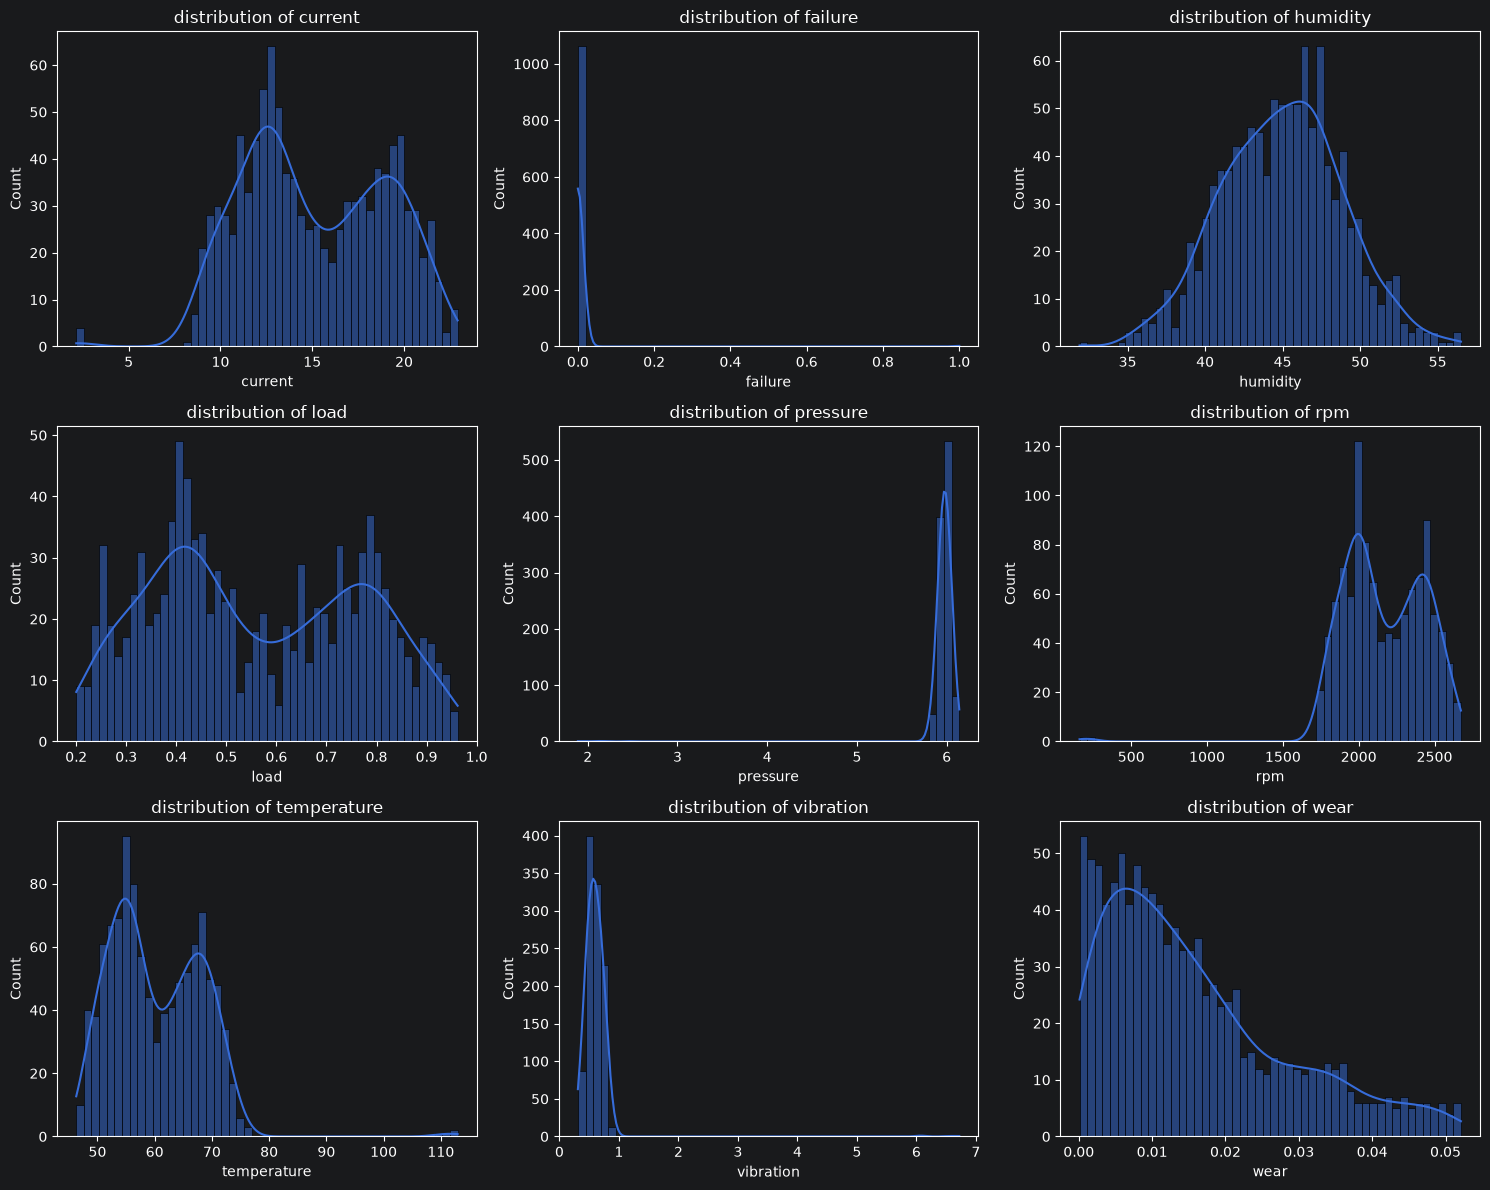

In [165]:
n_features = len(features)

fig, axes = plt.subplots(
    nrows=(n_features + 2) // 3,
    ncols=3,
    figsize=(15, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(f"distribution of {feature}")
    ax.set_xlabel(feature)

# remove unused axes
for ax in axes[n_features:]:
    ax.remove()

plt.tight_layout()
plt.show()

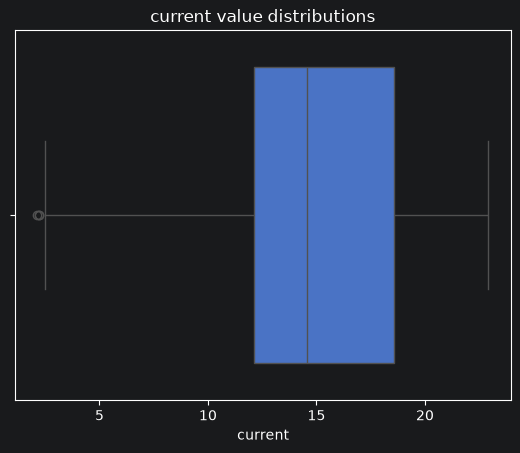

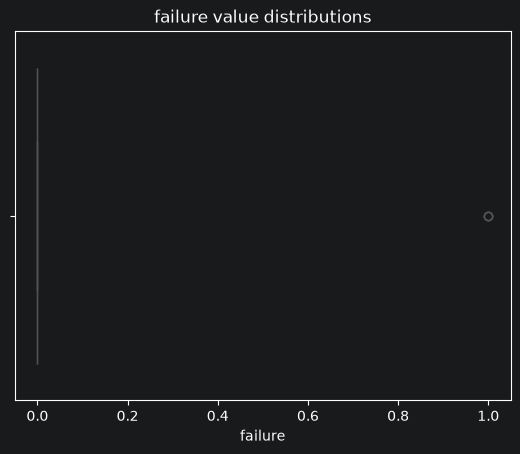

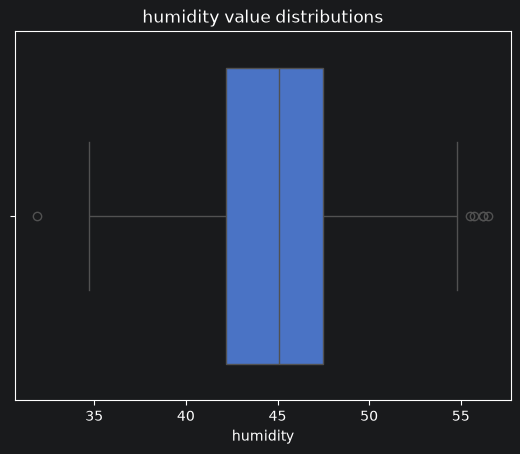

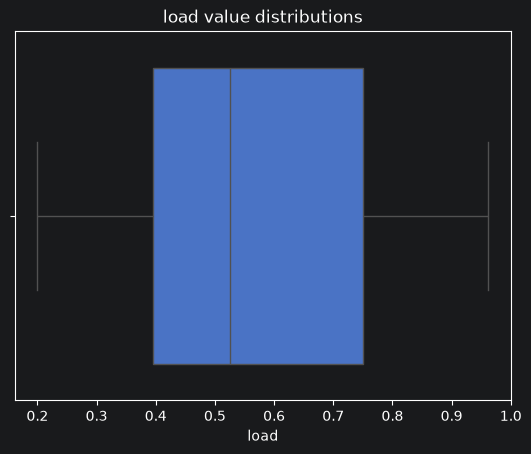

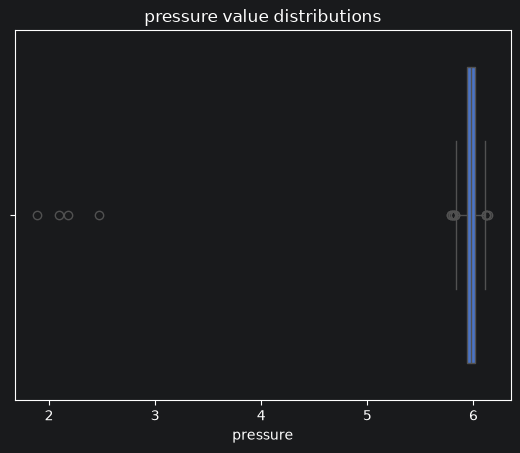

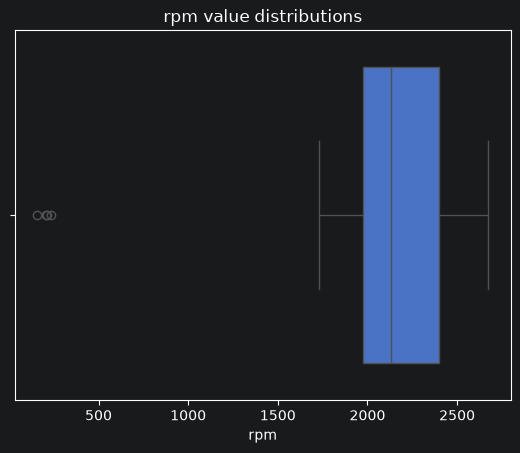

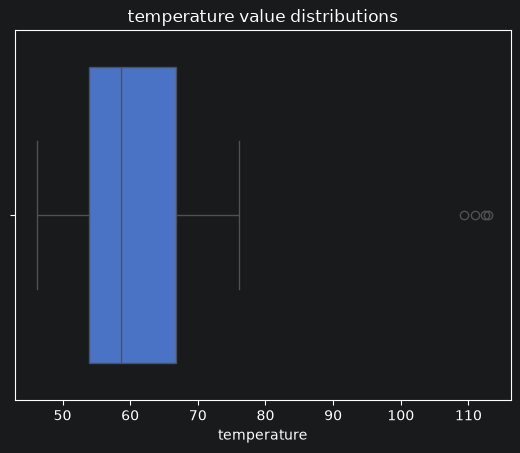

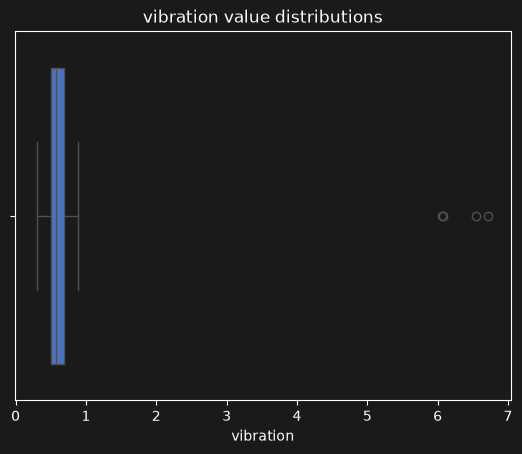

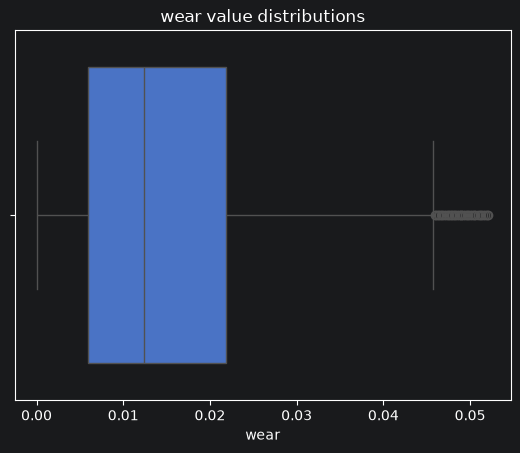

In [170]:
for feature in features:
    sns.boxplot(
        data=df,
        x=feature
    )

    plt.title(f"{feature} value distributions")
    plt.show()

## Correlation

In [178]:
corr = df[features].corr()

<Axes: >

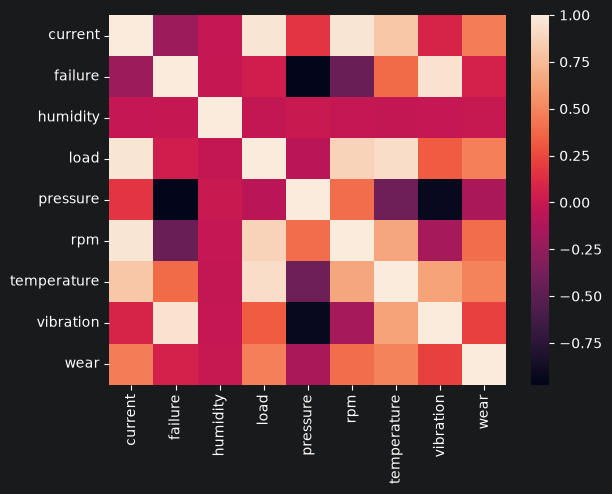

In [179]:
sns.heatmap(corr)

## Sensor dynamics

In [104]:
device = "motor_001"

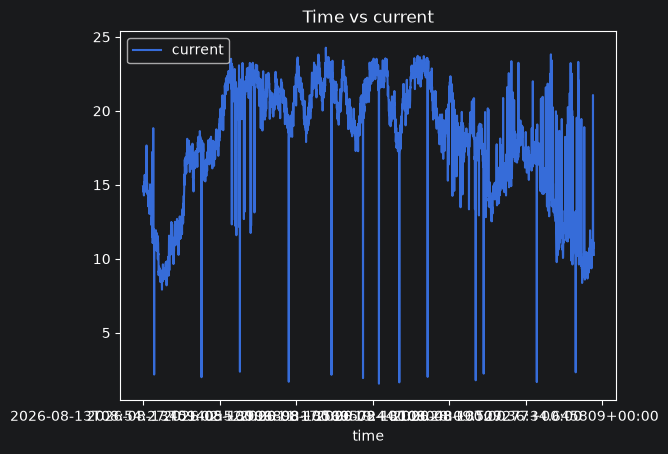

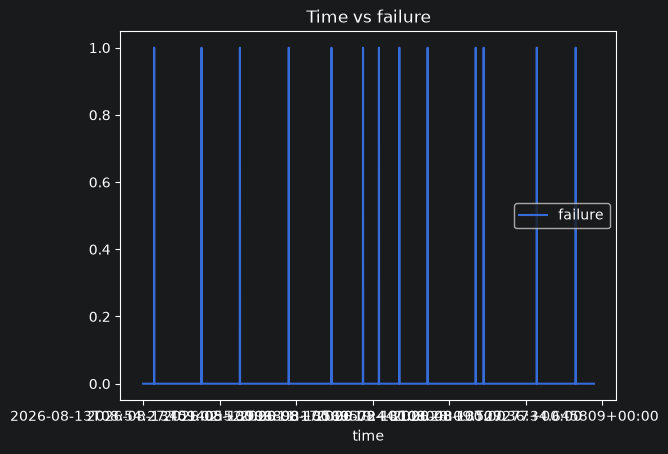

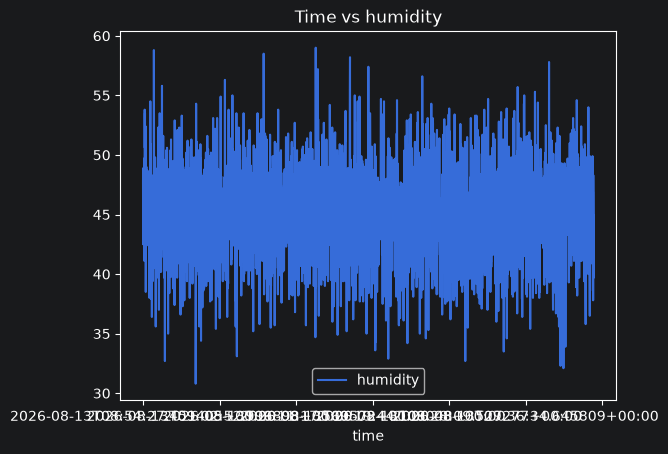

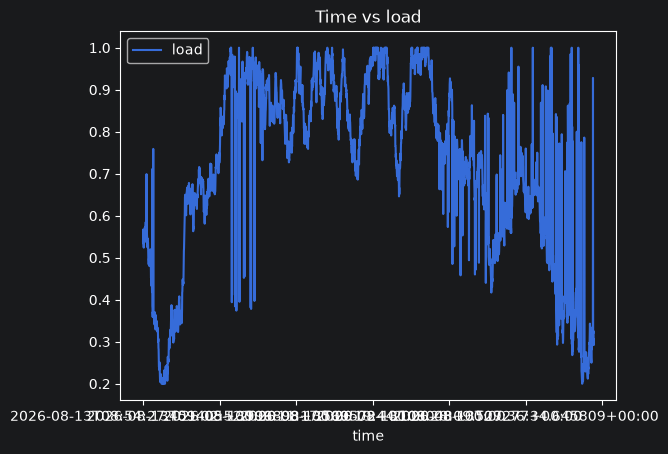

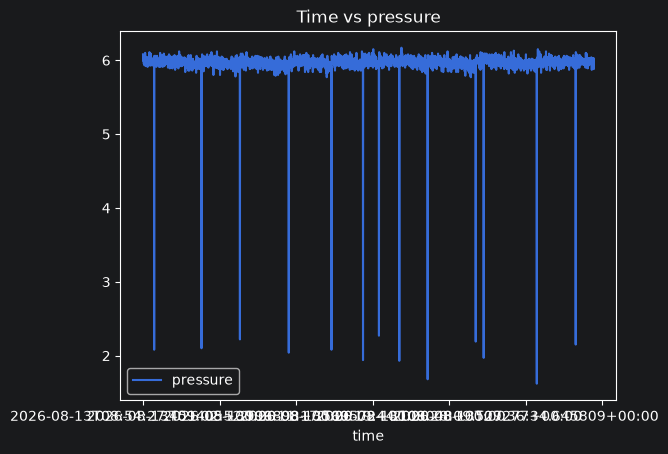

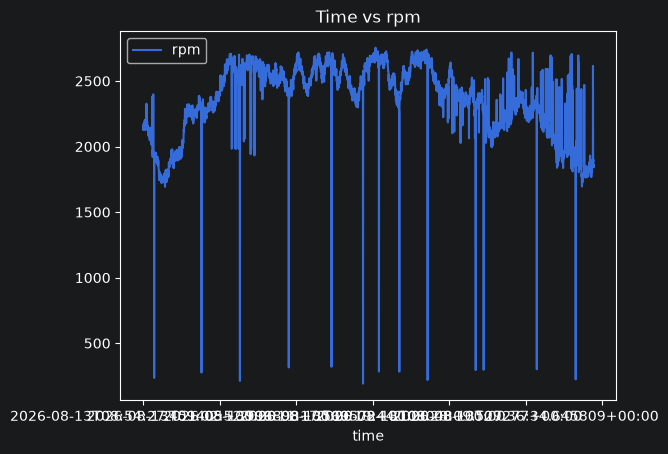

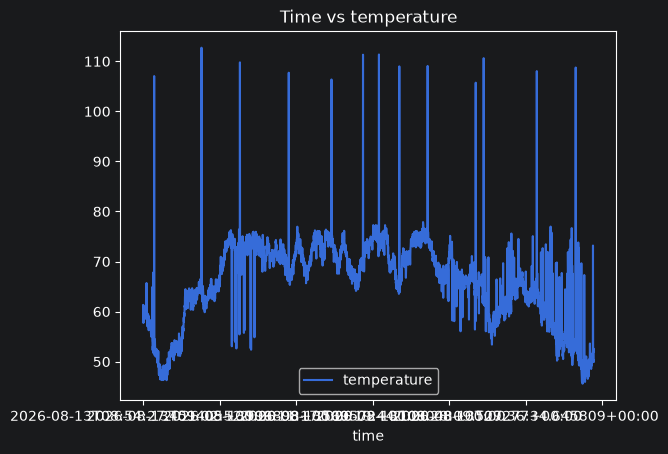

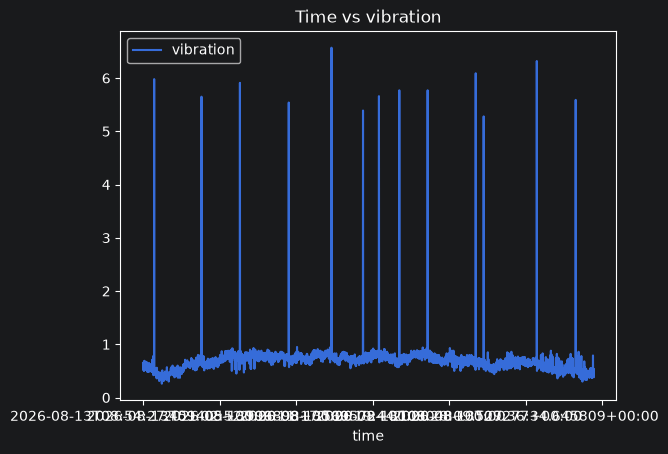

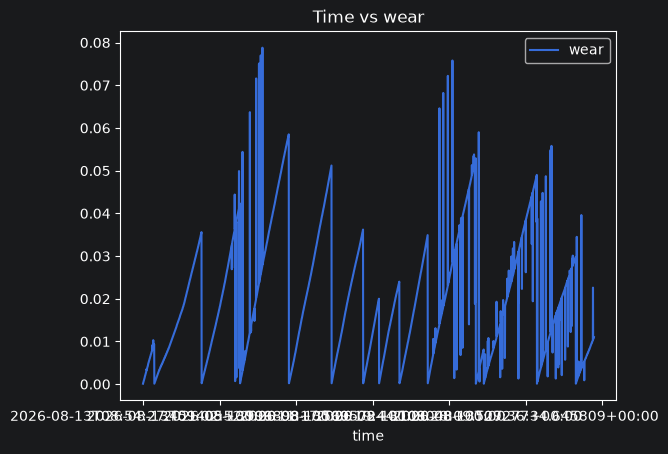

In [105]:
subset = df[df['device_id'] == device].drop(columns='device_id')

for feature in features:
    subset.plot(x='time',
                y=feature,
                title=f"Time vs {feature}")

looks like spikes in some features lead to spikes in failure, lets see

In [106]:
# time as index for faster plots
subset = subset.set_index('time')
subset.index = pd.to_datetime(subset.index)

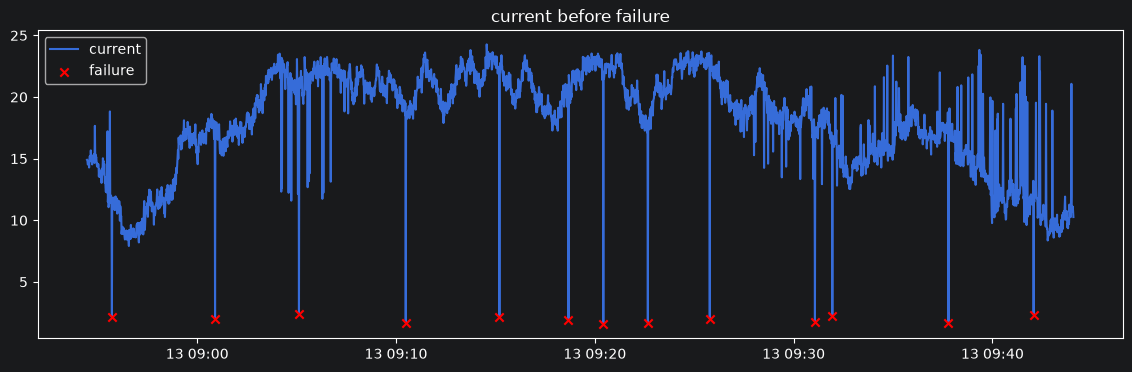

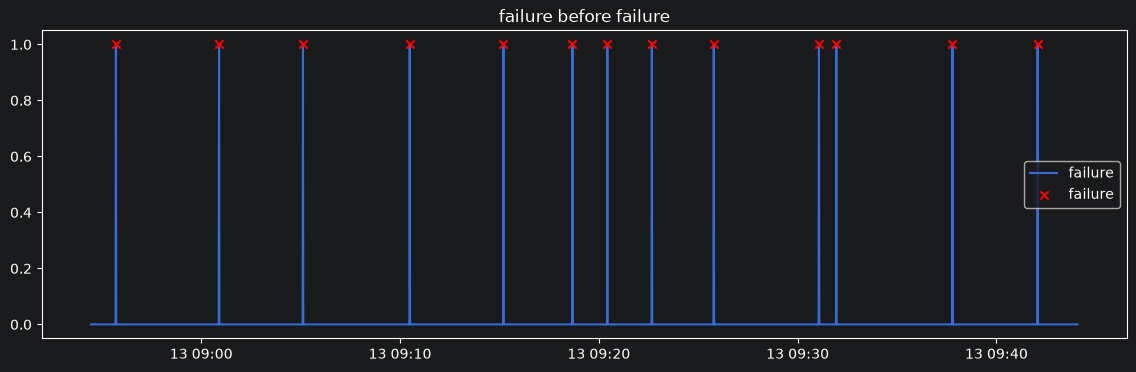

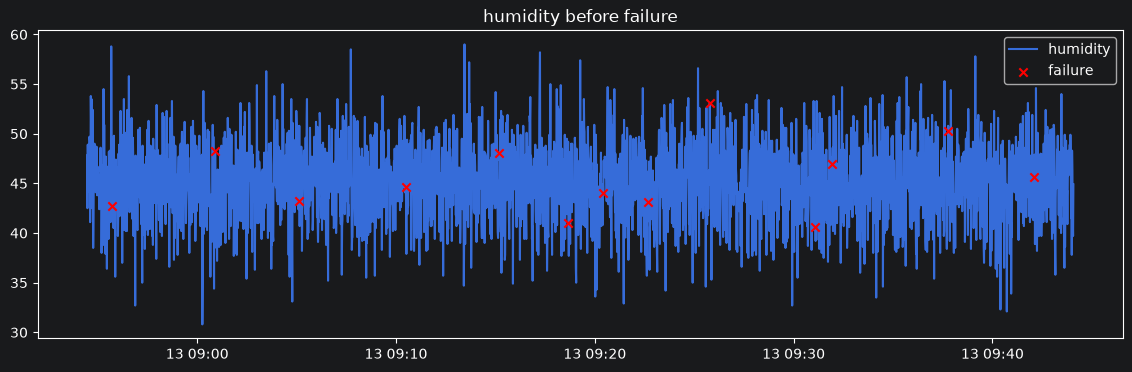

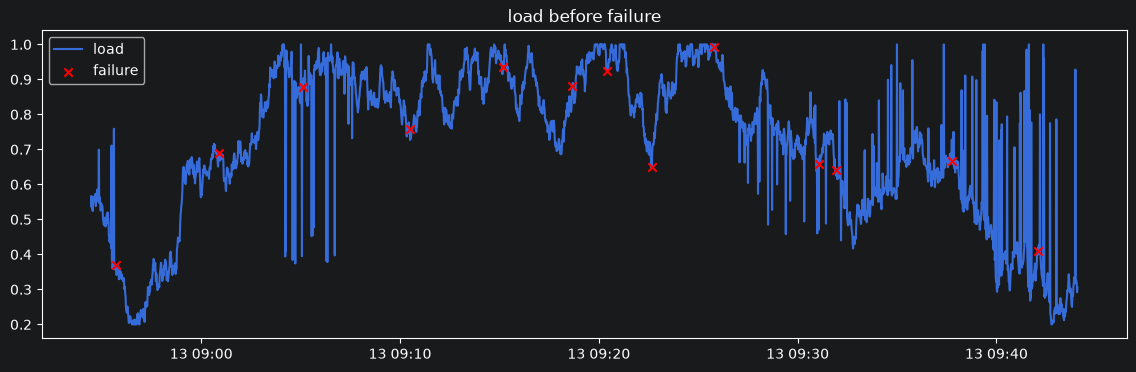

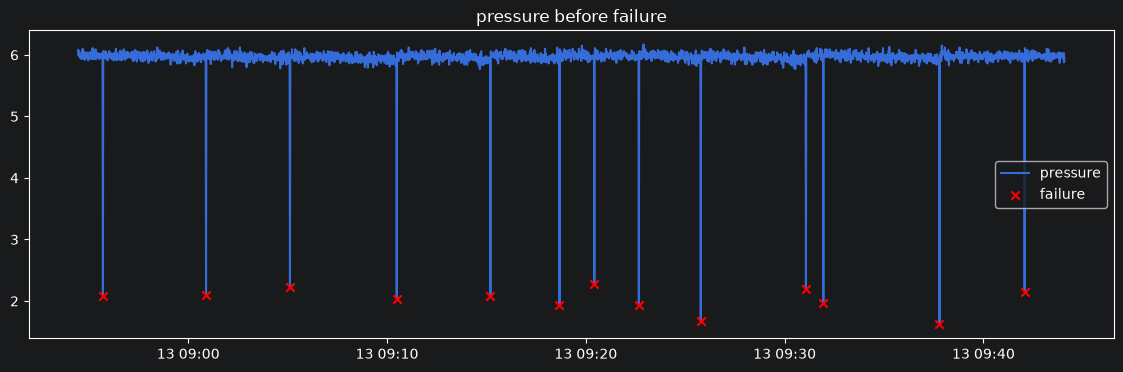

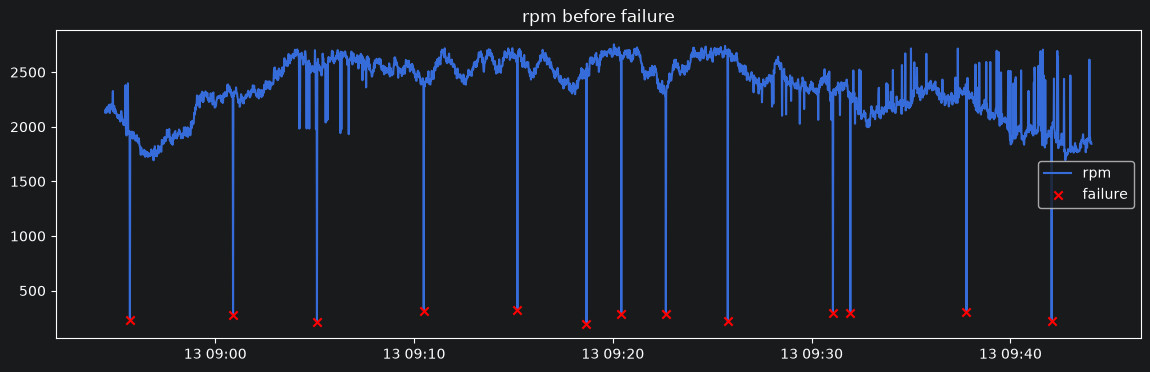

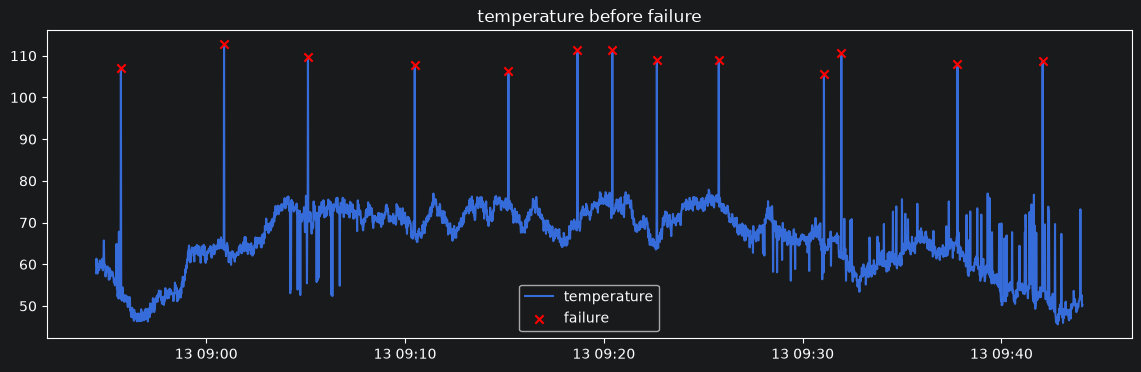

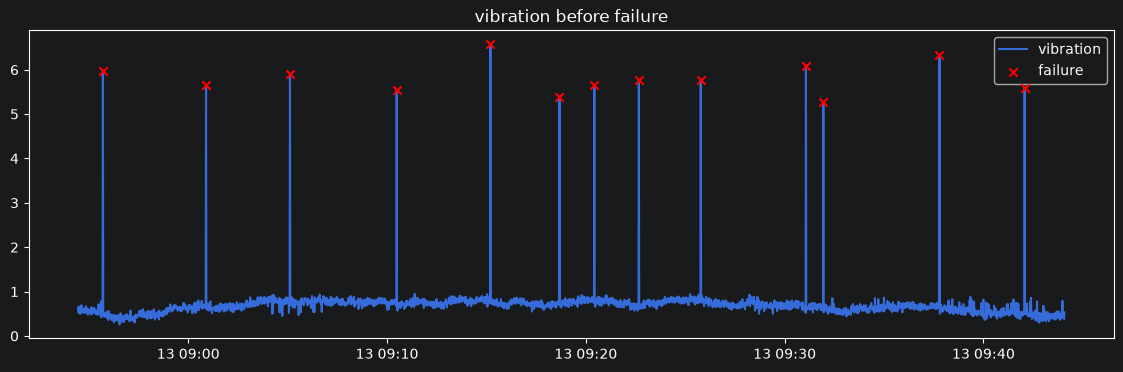

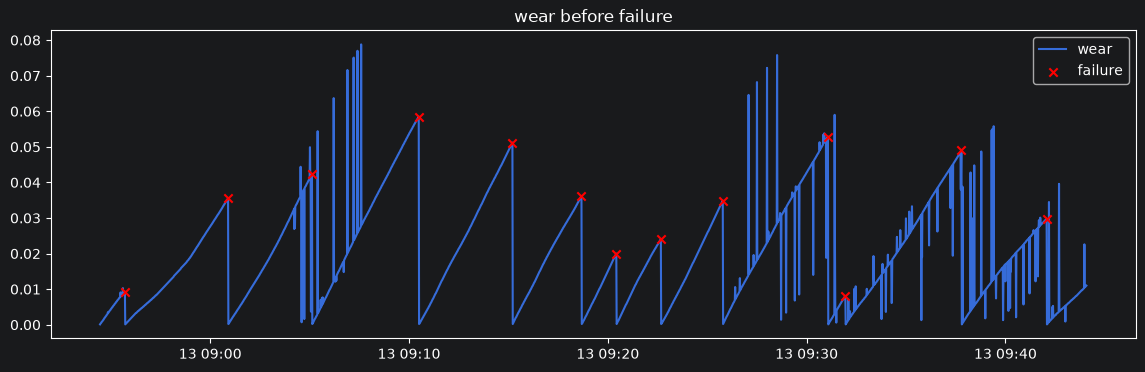

In [107]:
failure_points = subset[subset["failure"] == 1]

for feature in features:
    plt.figure(figsize=(14, 4))

    plt.plot(
        subset.index,
        subset[feature],
        label=feature,
        zorder=1
    )

    plt.scatter(
        failure_points.index,
        failure_points[feature],
        marker='x',
        label='failure',
        color='red',
        zorder=10
    )

    plt.title(f"{feature} before failure")
    plt.legend()
    plt.show()